# Лабораторная работа №5.3

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

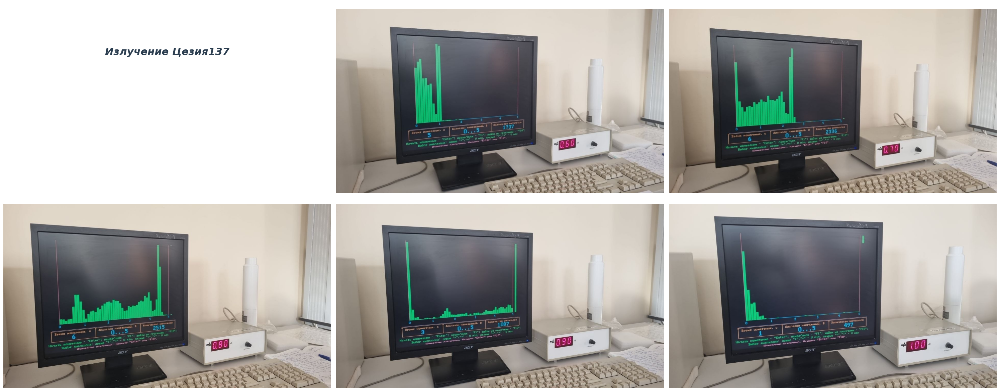

In [ ]:
folder = "./цезий137"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")], reverse=True)

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Излучение Цезия137",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

Исследуем зависимость положения фотопика γ квантов с E=661.7кэВ от напряжения на ФЭУ

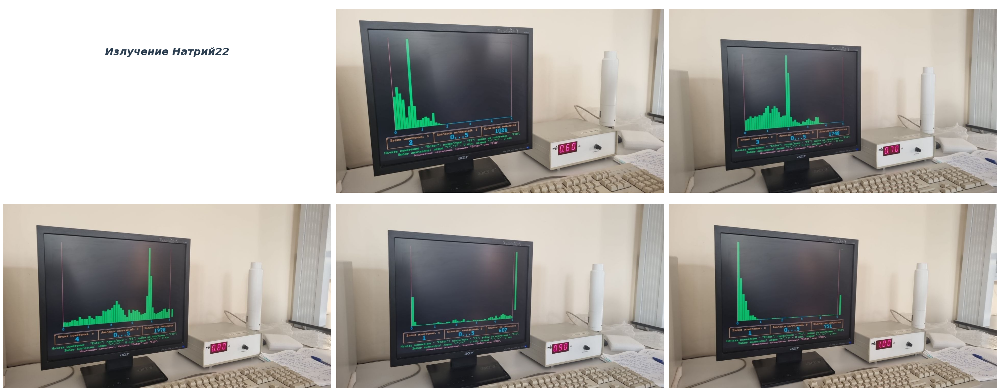

In [ ]:
folder = "./натрий22"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Излучение Натрий22",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

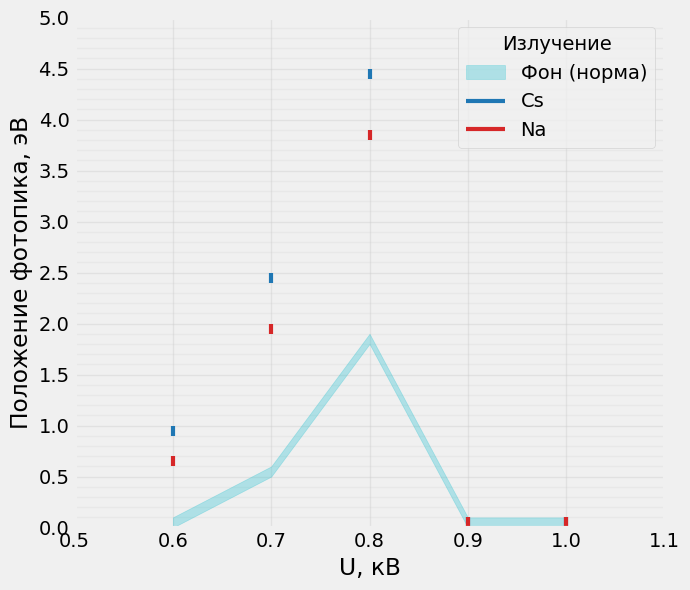

In [ ]:
dataCs = np.array([
    [0.6, 0.9, 0.1],
    [0.7, 2.4, 0.1],
    [0.8, 4.4, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataNa = np.array([
    [0.6, 0.6, 0.1],
    [0.7, 1.9, 0.1],
    [0.8, 3.8, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataBackgroundNormal = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.5, 0.1],
    [0.8, 1.8, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])


with plt.style.context('fivethirtyeight'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Фон — полупрозрачная голубая область
    ax.fill_between(
        dataBackgroundNormal[:, 0],
        dataBackgroundNormal[:, 1],
        dataBackgroundNormal[:, 1] + dataBackgroundNormal[:, 2],
        color='tab:cyan', alpha=0.3, label='Фон (норма)',
    )

    for data, color, label in [
        (dataCs, 'tab:blue', 'Cs'),
        (dataNa, 'tab:red',  'Na'),
    ]:
        x = data[:, 0]
        y = data[:, 1]
        w = data[:, 2]
        ax.vlines(x=x, ymin=y, ymax=y + w,
                  linewidth=3, color=color, label=label)

    ax.set_xlabel('U, кВ')
    ax.set_ylabel('Положение фотопика, эВ')

    ax.set_xlim(0.5, 1.1)
    ax.set_ylim(0, 5)

    ax.set_xticks(np.arange(0.5, 1.1 + 1e-9, 0.1))
    ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.1), minor=True)
    ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.5))

    ax.grid(True, which='minor', axis='y', alpha=0.2)
    ax.grid(True, which='major', alpha=0.4)

    ax.legend(title='Излучение')

plt.tight_layout()
plt.show()


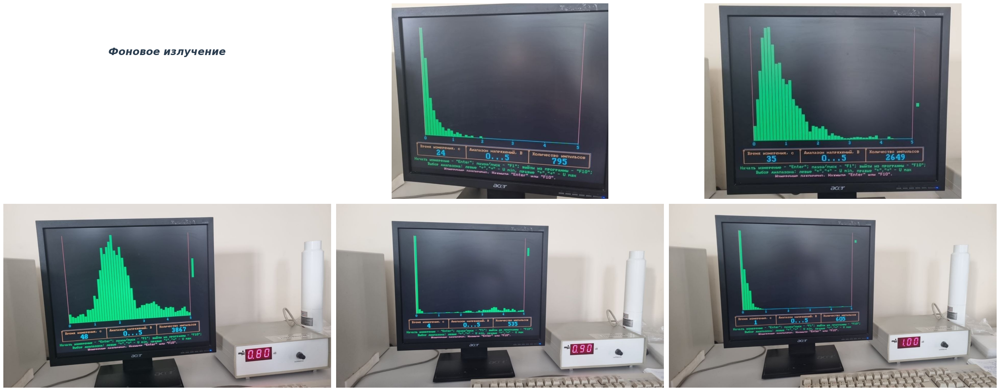

In [ ]:
folder = "./фон_обычный"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Фоновое излучение",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

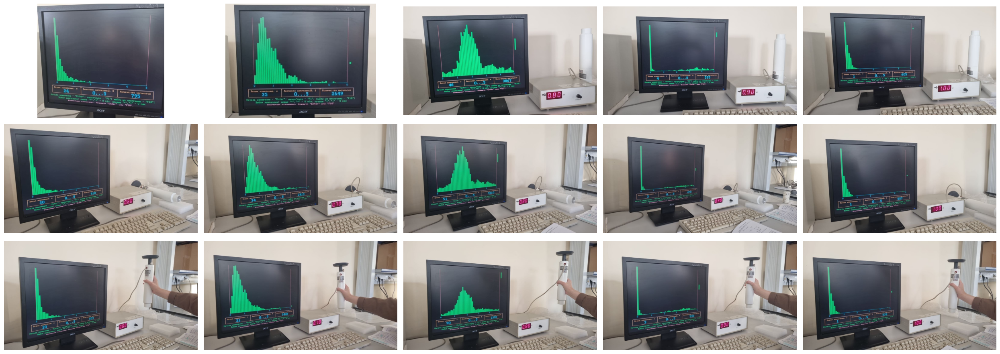

In [ ]:
folder = "./аниизотропия"

# Желаемая раскладка: (ряд, список времён)
# Ряд 0 -> 16-41-24, Ряд 1 -> 16-36-20, Ряд 2 -> 16-37-11
row_times = ["16-41-24", "16-36-20", "16-37-11"]

# Собираем все файлы
all_files = os.listdir(folder)

# Функция поиска файла по номеру и времени
def find_file(num, time_str):
    pattern = re.compile(rf"photo_{num}_.*{re.escape(time_str)}.*\.jpg$", re.IGNORECASE)
    for f in all_files:
        if pattern.search(f):
            return f
    return None

rows, cols = 3, 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3))
axes = axes.flatten()

for r, time_str in enumerate(row_times):
    for c in range(cols):
        idx = r * cols + c
        num = c + 1  # 1..5
        fname = find_file(num, time_str)
        ax = axes[idx]
        ax.axis("off")
        if fname is None:
            ax.text(0.5, 0.5, f"нет\nphoto_{num}_{time_str}",
                    ha="center", va="center", fontsize=10, color="red")
            continue
        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        ax.imshow(img)

plt.tight_layout()
plt.show()

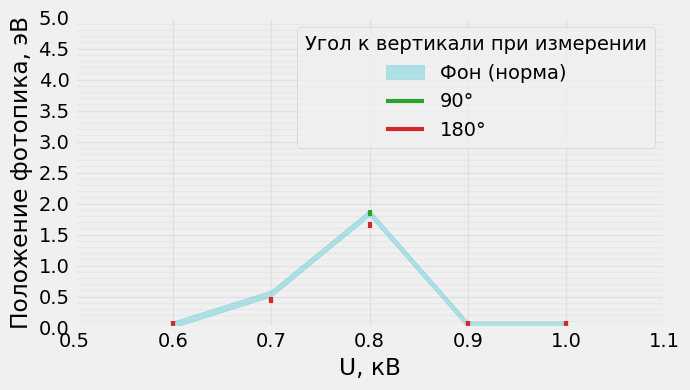

In [ ]:
dataBackgroundNormal = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.5, 0.1],
    [0.8, 1.8, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataBackgroundUpright = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.4, 0.1],
    [0.8, 1.8, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataBackgroundUpsideDown = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.4, 0.1],
    [0.8, 1.6, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])


with plt.style.context('fivethirtyeight'):
    fig, ax = plt.subplots(figsize=(7, 4))

    # Фон при нормальном положении — полупрозрачная голубая область
    ax.fill_between(
        dataBackgroundNormal[:, 0],
        dataBackgroundNormal[:, 1],
        dataBackgroundNormal[:, 1] + dataBackgroundNormal[:, 2],
        color='tab:cyan', alpha=0.3, label='Фон (норма)',
    )

    for data, color, label in [
        (dataBackgroundUpright, 'tab:green', '90°'),
        (dataBackgroundUpsideDown, 'tab:red', '180°'),
    ]:
        x = data[:, 0]
        y = data[:, 1]
        w = data[:, 2]
        ax.vlines(x=x, ymin=y, ymax=y + w,
                  linewidth=3, color=color, label=label)

    ax.set_xlabel('U, кВ')
    ax.set_ylabel('Положение фотопика, эВ')

    ax.set_xlim(0.5, 1.1)
    ax.set_ylim(0, 5)

    ax.set_xticks(np.arange(0.5, 1.1 + 1e-9, 0.1))
    ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.1), minor=True)
    ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.5))

    ax.grid(True, which='minor', axis='y', alpha=0.2)
    ax.grid(True, which='major', alpha=0.4)

    ax.legend(title='Угол к вертикали при измерении')

plt.tight_layout()
plt.show()

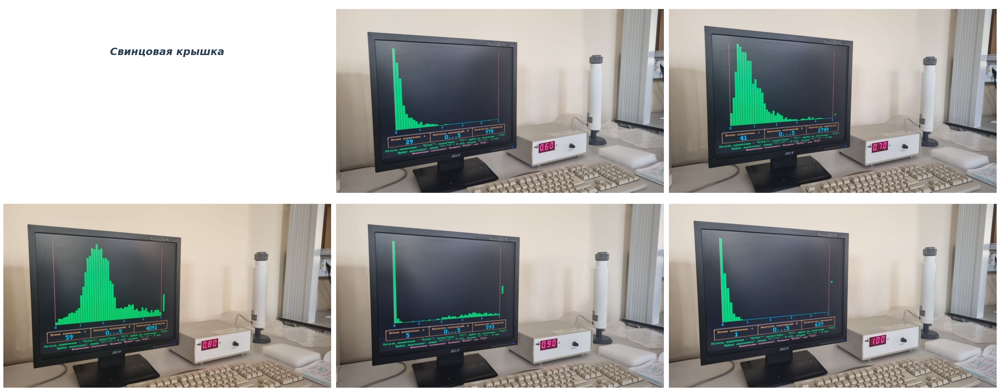

In [ ]:
folder = "./крышка"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Свинцовая крышка",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

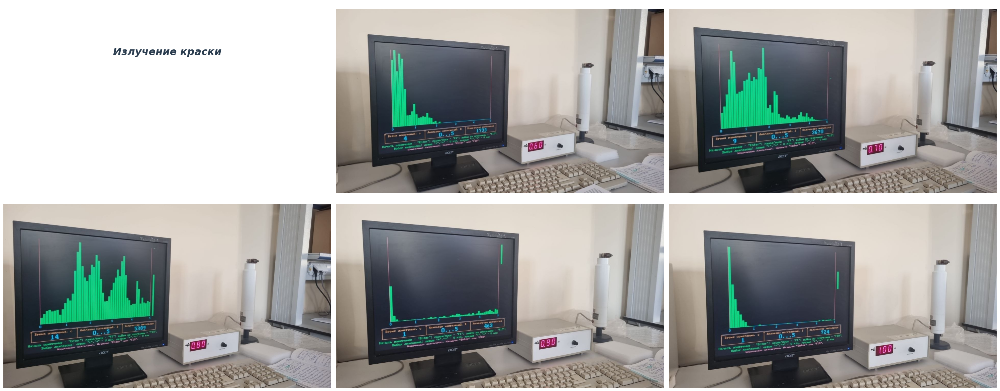

In [ ]:
folder = "./краска"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")], reverse=True)
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Излучение краски",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

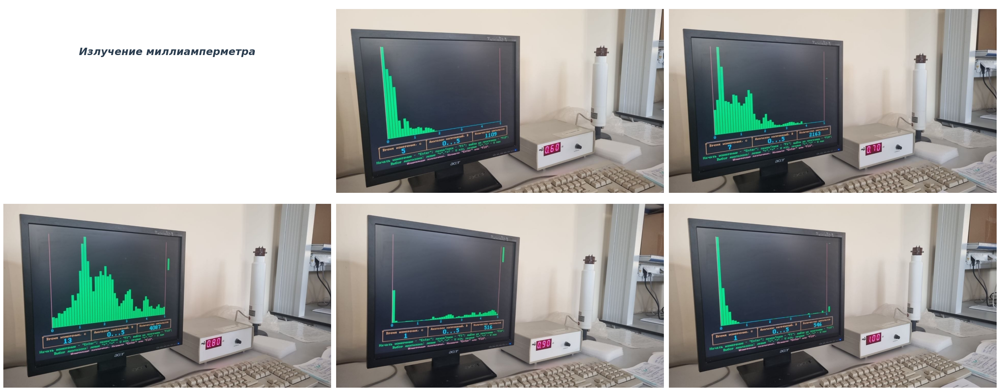

In [ ]:
folder = "./миллиамперметр"
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 6))
axes = axes.flatten()

# Первая ячейка — пустая с надписью
axes[0].axis("off")
axes[0].text(0.5, 0.75, "Излучение миллиамперметра",
             ha="center", va="center",
             fontsize=22, fontweight="bold",
             color="#2c3e50", style="italic")

# Остальные ячейки — картинки
for i, fname in enumerate(files):
    if i + 1 >= len(axes):
        break
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

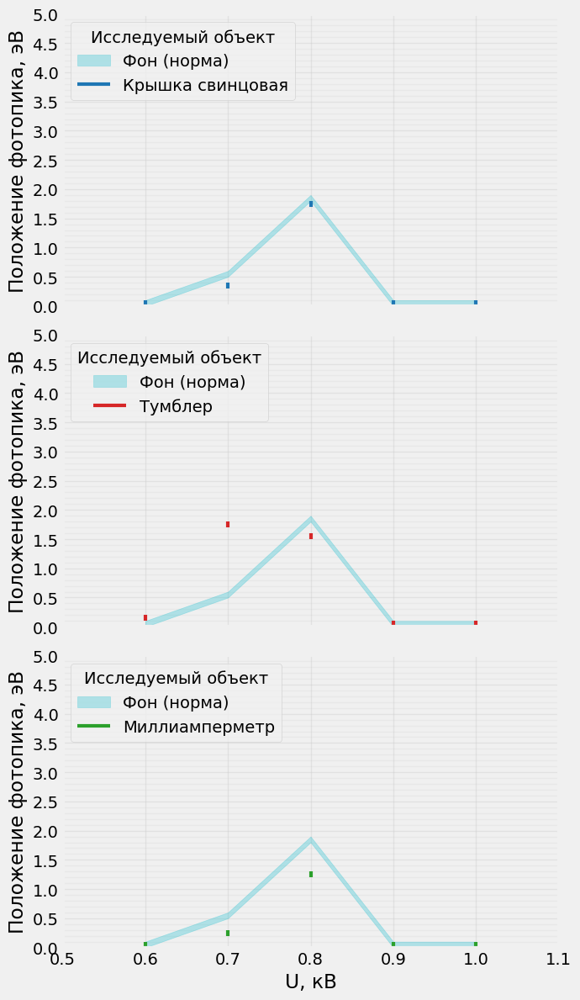

In [ ]:
dataBackgroundNormal = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.5, 0.1],
    [0.8, 1.8, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataPb = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.3, 0.1],
    [0.8, 1.7, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataPaint = np.array([
    [0.6, 0.1, 0.1],
    [0.7, 1.7, 0.1],
    [0.8, 1.5, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])

dataMilliampere = np.array([
    [0.6, 0.0, 0.1],
    [0.7, 0.2, 0.1],
    [0.8, 1.2, 0.1],
    [0.9, 0.0, 0.1],
    [1.0, 0.0, 0.1],
])


objects = [
    (dataPb, 'tab:blue', 'Крышка свинцовая'),
    (dataPaint, 'tab:red', 'Тумблер'),
    (dataMilliampere, 'tab:green', 'Миллиамперметр'),
]

with plt.style.context('fivethirtyeight'):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 12), sharex=True, sharey=True)

    for ax, (data, color, label) in zip(axes, objects):
        x = data[:, 0]
        y = data[:, 1]
        w = data[:, 2]

        # Фон — полупрозрачная голубая область
        ax.fill_between(
            dataBackgroundNormal[:, 0],
            dataBackgroundNormal[:, 1],
            dataBackgroundNormal[:, 1] + dataBackgroundNormal[:, 2],
            color='tab:cyan', alpha=0.3, label='Фон (норма)',
        )

        # Исследуемый объект — вертикальные линии
        ax.vlines(x=x, ymin=y, ymax=y + w,
                  linewidth=3, color=color, label=label)

        ax.set_ylabel('Положение фотопика, эВ')
        ax.set_ylim(0, 5)
        ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.1), minor=True)
        ax.set_yticks(np.arange(0.0, 5.0 + 1e-9, 0.5))
        ax.grid(True, which='minor', axis='y', alpha=0.2)
        ax.grid(True, which='major', alpha=0.4)
        ax.legend(title='Исследуемый объект', loc='upper left')

    axes[-1].set_xlabel('U, кВ')
    axes[-1].set_xlim(0.5, 1.1)
    axes[-1].set_xticks(np.arange(0.5, 1.1 + 1e-9, 0.1))

plt.tight_layout()
plt.show()

 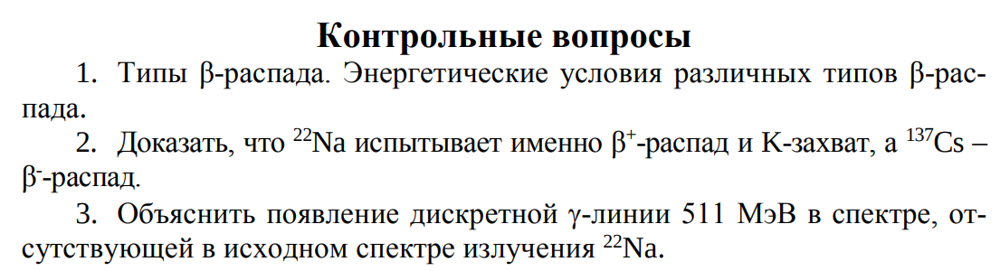

#1
Бета распад - процесс самопроизвольного превращения нестабильного ядра в ядро-изобару (ядро с тем же атомным номером) с зарядом, отличным от исходного на +-1 за счет испускания электрона (позитрона) или захвата электрона с атомной оболочки.

#2

#3